## 3. Entrenamiento

In [14]:
import pandas as pd
import random
from sklearn.model_selection import train_test_split # Modelado
from sklearn.pipeline import Pipeline # Modelado
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer # Modelado
from sklearn.feature_selection import chi2 # Reporte
from sklearn.linear_model import LogisticRegression # Reporte
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve # Reporte

import matplotlib.pyplot as plt

In [3]:
# Cargar DataFrame desde el archivo guardado en el notebook Carga y exploración
df = pd.read_pickle('Data/df_beauty_preprocessed_ML.pkl')
print(f"DataFrame cargado: {len(df)} reviews")
df.head()

DataFrame cargado: 5990 reviews


,review_process_lemma,sentiment_label
0,"[product, oil, based, weird, definitely, work,...",0
1,"[shown, expensive, like, alabama, fell, love, ...",0
2,"[buy, use, original, product, small, it, thoug...",1
3,"[product, advertised, brand, new, however, box...",1
4,"[new, edition, daughter, body, spray, loved, s...",0


In [48]:
# Verificar qué columnas tiene el DataFrame
print("Columnas disponibles:")
print(df.columns.tolist())
print(f"\nPrimera fila:")
print(df.iloc[0])

Columnas disponibles:
['review_process_lemma', 'sentiment_label']

Primera fila:
review_process_lemma    [product, oil, based, weird, definitely, work,...
sentiment_label                                                         0
Name: 0, dtype: object


### Separo en conjunto de Train (75%) y Test(25%)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review_process_lemma'],
    df['sentiment_label'],
    train_size=0.75,
    test_size=0.25,
    random_state=42,
    shuffle=True
)

In [6]:
X_train.iloc[:10]

2407               [perfect, short, fine, bleached, hair]
5509                                      [dry, received]
4056    [flat, iron, super, perfect, short, cut, youre...
4945    [brass, hair, groom, creme, year, best, stuff,...
4856    [daughter, face, bad, pimple, forehead, area, ...
2302    [swear, wig, look, way, nicer, person, adverti...
1669              [nice, one, good, helper, shower, time]
1410                                              [small]
4333    [product, time, rd, time, stopped, working, pr...
3286    [cute, bag, size, perfect, but, check, specifi...
Name: review_process_lemma, dtype: object

In [8]:
# Convertir listas de palabras a strings (TfidfVectorizer necesita texto)
X_train_text = X_train.apply(lambda x: ' '.join(x))
X_test_text = X_test.apply(lambda x: ' '.join(x))

print(f"Ejemplo de texto procesado:")
print(X_train_text.iloc[0])

Ejemplo de texto procesado:
perfect short fine bleached hair


### Extracción de caracteristicas con TF-IDF 

- Como estamos hablando de un dataset pequeño de 6000 reviews escogemos los parámetros de la siguiente manera como primer aaproximación:
- ngram_range: bigrama paara capturar pares de palabras (importante en analisis de sentimiento captura el "not good, very bad")
- max_features: 4000 para no tener overfitting
- min_df: 3 al menos para generalizar mejor
- max_df: 0.85 ignorando palabras muy comunes

In [10]:
cv = TfidfVectorizer(
    max_df=0.85,
    min_df=5,
    max_features=4000,
    strip_accents='ascii',
    ngram_range=(1, 2)
)


In [ ]:
cv.fit(X_train_text)

print(f"Vocabulario TF-IDF: {len(cv.vocabulary_)} features")
print(f"Ejemplos de features: {list(cv.vocabulary_.keys())[:10]}")

Vocabulario TF-IDF: 2792 features
Ejemplos de features: ['perfect', 'short', 'fine', 'bleached', 'hair', 'dry', 'received', 'flat', 'iron', 'super']


In [12]:
X_train_ = cv.transform(X_train_text)
X_test_ = cv.transform(X_test_text)

### Analizamos las palabras más importantes de una review cualquiera según TF-IDF y así vemos cuales está teniendo en cuenta el modelo como más relevantes de cara a la clasificación

In [19]:
i = random.randint(0, len(X_train))
print('ID: {}'.format(i))
print('Sentiment: {}'.format(y_train.iloc[i]))
print('Review: {}'.format(X_train.iloc[i]))

ID: 3568
Sentiment: 0
Review: ['comfortable', 'fabric', 'super', 'soft', 'help', 'having', 'wear', 'mask', 'day', 'save', 'ear', 'headache', 'strap', 'ear', 'design', 'cute', 'plenty', 'variety', 'multiple', 'outfit']


In [20]:
doc_vector = X_train_[i]
df_tfidf = pd.DataFrame(doc_vector.T.todense(), index=cv.get_feature_names_out(), columns=['tfidf'])
df_tfidf = df_tfidf[df_tfidf['tfidf'] > 0]

top_n = 5
print('Top {} palabras con alto TF_IDF en la review {}:\n{}'.format(top_n, i, df_tfidf.sort_values(by=["tfidf"],ascending=False)[:top_n]))
print('\nTop {} palabras con bajo TF_IDF en la review {}:\n{}'.format(top_n, i, df_tfidf.sort_values(by=["tfidf"],ascending=False)[-top_n:]))

Top 5 palabras con alto TF_IDF en la review 3568:
             tfidf
ear       0.451870
outfit    0.264895
variety   0.251390
headache  0.248669
strap     0.246135

Top 5 palabras con bajo TF_IDF en la review 3568:
          tfidf
wear   0.173638
cute   0.172632
super  0.165716
soft   0.154675
day    0.145087


<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
/var/folders/vr/j_49s7z54f58kwyv69jtls9h0000gp/T/ipykernel_82966/109972082.py:14: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel('$\chi^2$', fontsize=26)
/var/folders/vr/j_49s7z54f58kwyv69jtls9h0000gp/T/ipykernel_82966/109972082.py:16: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Top {} $\chi^2$ score for each word in the training set'.format(i), fontsize=20)


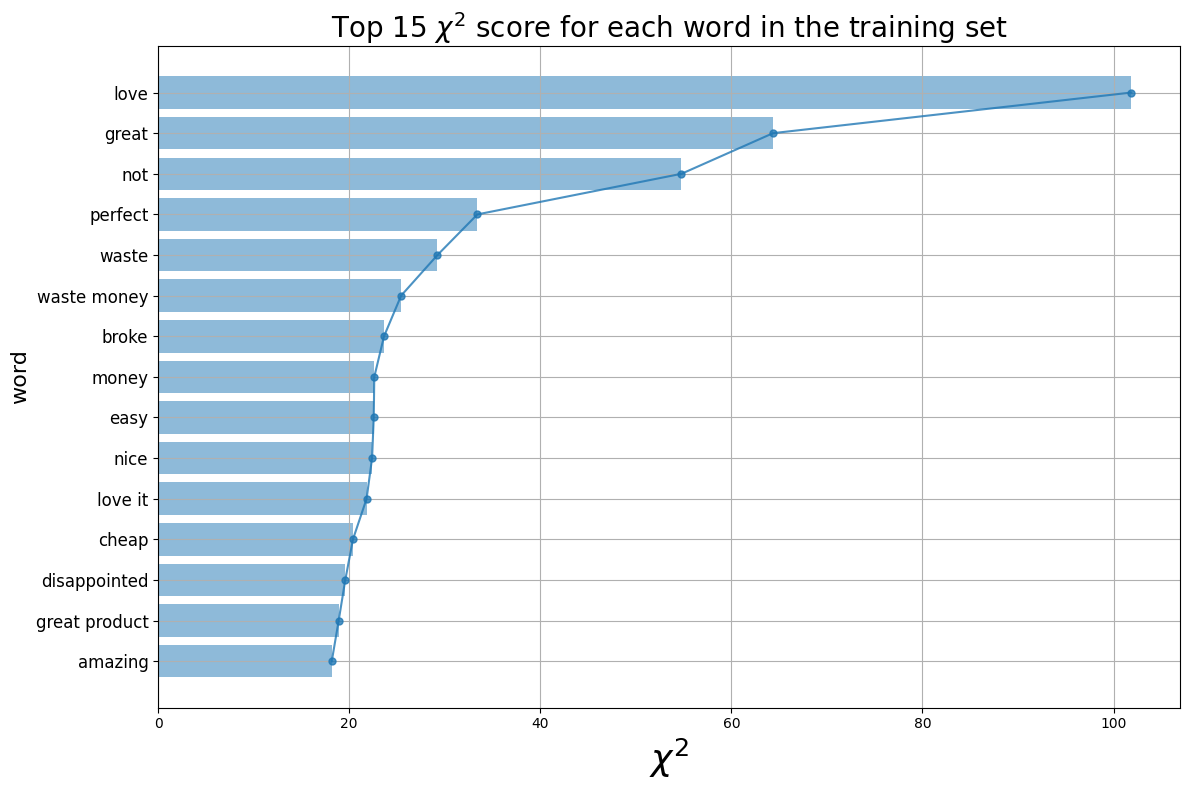

In [21]:
i = 15

chi2score = chi2(X_train_, y_train)[0]
scores = list(zip(cv.get_feature_names_out(), chi2score))
sorted_scores = sorted(scores, key=lambda x:x[1])
topchi2 = list(zip(*sorted_scores[-i:]))
x = range(len(topchi2[1]))
labels = topchi2[0]

plt.figure(figsize=(12, 8))
plt.barh(x,topchi2[1], align='center', alpha=0.5)
plt.plot(topchi2[1], x, '-o', markersize=5, alpha=0.8)
plt.yticks(x, labels, fontsize=12)
plt.xlabel('$\chi^2$', fontsize=26)
plt.ylabel('word', fontsize=16)
plt.title('Top {} $\chi^2$ score for each word in the training set'.format(i), fontsize=20)
plt.grid()
plt.tight_layout()
plt.show();

- Palabras como "waste", "waste money", "disappointed" probablemente indican reviews negativas
- Palabras como "love", "great", "perfect" probablemente indican reviews positivas

### Entrenamiento de modelo de ML `LogisticRegression` con búsqueda de mejor hiperparámetro

In [23]:
c_params = [0.01, 0.05, 0.25, 0.5, 1, 10, 100, 1000, 5000]

train_acc = list()
test_acc = list()
for c in c_params:
    lr = LogisticRegression(C=c, solver='lbfgs', max_iter=500)
    lr.fit(X_train_, y_train)

    train_predict = lr.predict(X_train_)
    test_predict = lr.predict(X_test_)

    print ("Accuracy for C={}: {}".format(c, accuracy_score(y_test, test_predict)))

    train_acc.append(accuracy_score(y_train, train_predict))
    test_acc.append(accuracy_score(y_test, test_predict))

Accuracy for C=0.01: 0.8164218958611482
Accuracy for C=0.05: 0.822429906542056
Accuracy for C=0.25: 0.8264352469959947
Accuracy for C=0.5: 0.8331108144192256
Accuracy for C=1: 0.8411214953271028
Accuracy for C=10: 0.8324432576769025
Accuracy for C=100: 0.8177570093457944
Accuracy for C=1000: 0.8124165554072096
Accuracy for C=5000: 0.8164218958611482


In [24]:
print('Confussion matrix:\n{}'.format(confusion_matrix(y_test, test_predict)))
print('\nClassification report:\n{}'.format(classification_report(y_test, test_predict)))
print('Accuracy score:{}'.format(accuracy_score(y_test, test_predict)))

Confussion matrix:
[[588 138]
 [137 635]]

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       726
           1       0.82      0.82      0.82       772

    accuracy                           0.82      1498
   macro avg       0.82      0.82      0.82      1498
weighted avg       0.82      0.82      0.82      1498

Accuracy score:0.8164218958611482


#### Las métricas indican un buen modelo en general. Nno esta desbalanceado (F1-score sin sesgo hacia ninguna clase), pero esto ya lo habiamos "forzado" a que estuviera balanceado. Alto recall negativo, lo que indica que el modelo es sensible a detectar reviews negativas. 

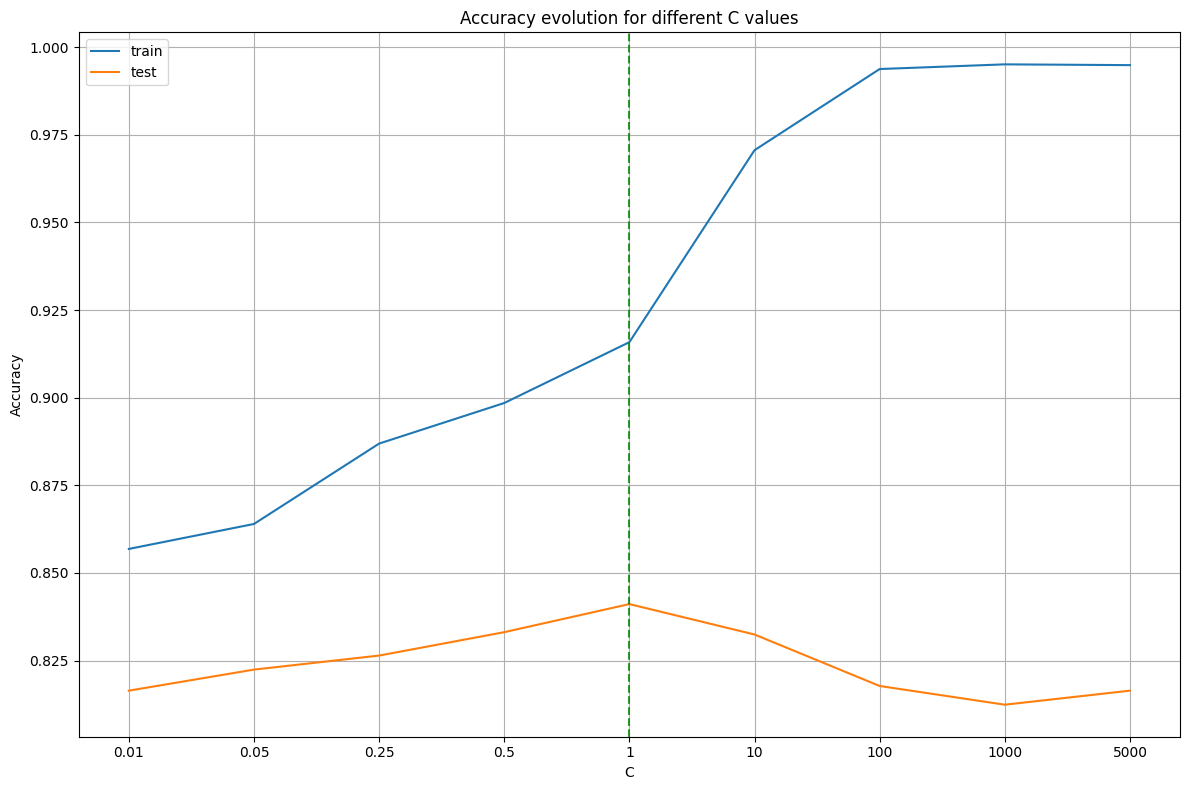

In [25]:
plt.figure(figsize=(12, 8))
plt.plot(train_acc, label='train')
plt.plot(test_acc, label='test')
plt.axvline(np.argmax(test_acc), c='g', ls='--', alpha=0.8)
plt.title('Accuracy evolution for different C values')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.xticks(list(range(len(c_params))), c_params)
plt.tight_layout()
plt.show()

#### Elegimos el valor de C donde test (linea naranja) alcanza el máximo antes de que empiece a bajar (C=1. acc=0.84) 

In [ ]:
# Re-entreno con el mejor C (C=1)
best_c = 1
lr_final = LogisticRegression(C=best_c, solver='lbfgs', max_iter=500)
lr_final.fit(X_train_, y_train)

# Evaluar el modelo final
y_pred_final = lr_final.predict(X_test_)
print(f"Modelo final con C={best_c}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_final)}")

Modelo final con C=1
Accuracy: 0.8411

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       726
           1       0.82      0.89      0.85       772

    accuracy                           0.84      1498
   macro avg       0.84      0.84      0.84      1498
weighted avg       0.84      0.84      0.84      1498



In [54]:
# Calculo la probabilidad de clase 1 (negativa) usando el modelo final con C=1
y_scores = lr_final.predict_proba(X_test_)[:, 1]  
# Especificar pos_label=1 explícitamente para clase negativa
p, r, thresholds = precision_recall_curve(y_test, y_scores, pos_label=1)

print(f"Puntos en la curva: {len(p)}")
print(f"Recall inicial (threshold bajo): {r[0]:.3f}")
print(f"Precision inicial (threshold bajo): {p[0]:.3f}")

Puntos en la curva: 1445
Recall inicial (threshold bajo): 1.000
Precision inicial (threshold bajo): 0.515


In [57]:
# Diagnóstico del problema
print("Distribución de clases en test:")
print(y_test.value_counts())
print(f"\nProporción clase 1 (negativa): {y_test.mean():.3f}")

# Verificar predicciones
print(f"\nDistribución de predicciones:")
print(pd.Series(y_pred_final).value_counts())

# Baseline: si siempre predices la clase mayoritaria
from collections import Counter
print(f"\nBaseline accuracy (siempre clase mayoritaria): {max(Counter(y_test).values()) / len(y_test):.3f}")

Distribución de clases en test:
sentiment_label
1    772
0    726
Name: count, dtype: int64

Proporción clase 1 (negativa): 0.515

Distribución de predicciones:
1    834
0    664
Name: count, dtype: int64

Baseline accuracy (siempre clase mayoritaria): 0.515


In [58]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.figure(figsize=(8, 8))
    plt.title("Precision and Recall Scores as a function of the decision threshold")
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.ylabel("Score")
    plt.xlabel("Decision Threshold")
    plt.legend(loc='best')

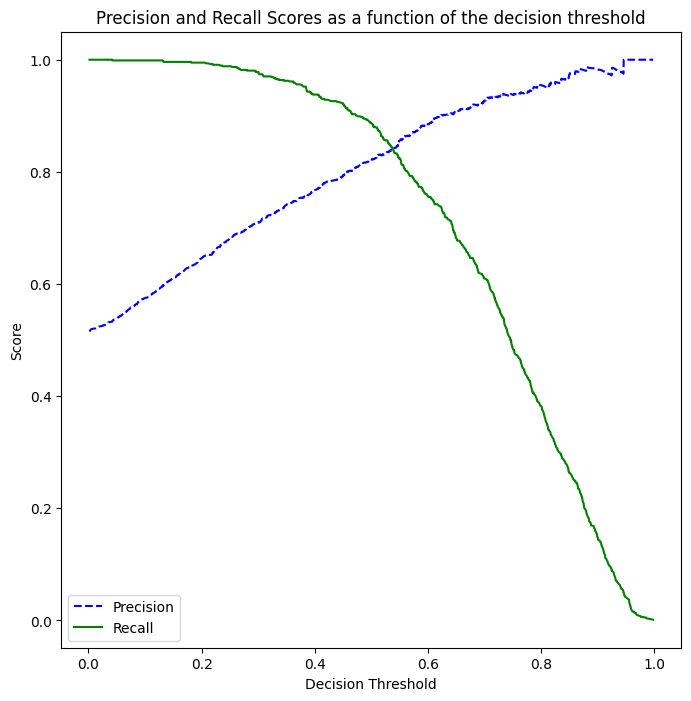

In [59]:
plot_precision_recall_vs_threshold(p, r, thresholds)

#### Algunas conclusiones del gráfico:

- Threshold bajo = 0.0-0.1: Recall ~100%, Precision ~52%
Detecta casi todas las reviews negativas pero clasificas muchas positivas erróneamente como negativas. 
- Threshold = 0.4-0.5 (zona óptima): Recall ~82-85%, Precision ~82-85%
Ahora cuando predice negativo acierta el 85% de las veces aprox
- Threshold = 0.9-1.0: Recall cae a ~1%, Precision ~98%
Casi siempre acierta cuando es negativa

#### Algunos ejemplos de predicciones con este modelo:

In [60]:
def predict_review_sentiment(review_index, model):
    # Intentar obtener texto original, si no existe usar el procesado
    if 'review' in df.columns:
        original_text = df.iloc[review_index]['review']
        print(f'Review original: {original_text[:200]}...')
    else:
        # Mostrar texto procesado reconstruido
        processed_words = df.iloc[review_index]['review_process_lemma']
        processed_text = ' '.join(processed_words)
        print(f'Review procesada: {processed_text[:200]}...')
    
    # Sentimiento real
    actual = df.iloc[review_index]['sentiment_label']
    print(f'Actual sentiment: {"Negative (1)" if actual == 1 else "Positive (0)"}')
    
    # Predicción
    r = df.iloc[review_index]['review_process_lemma']
    r_text = ' '.join(r)
    prediction = model.predict(cv.transform([r_text]))[0]
    proba = model.predict_proba(cv.transform([r_text]))[0]
    
    print(f'Prediction: {"Negative (1)" if prediction == 1 else "Positive (0)"}')
    print(f'Probabilities: [Positive: {proba[0]:.3f}, Negative: {proba[1]:.3f}]')
    print(f'Match: {"✓" if actual == prediction else "✗"}')

In [71]:
for i in random.sample(range(0, len(df)), 5):
    print('\nReview no. {}'.format(i))
    predict_review_sentiment(i, lr_final)


Review no. 3099
Review procesada: color pretty but it hard use familiar poly gel...
Actual sentiment: Positive (0)
Prediction: Positive (0)
Probabilities: [Positive: 0.605, Negative: 0.395]
Match: ✓

Review no. 723
Review procesada: filter not secure sewn in loose fit poorly...
Actual sentiment: Negative (1)
Prediction: Negative (1)
Probabilities: [Positive: 0.227, Negative: 0.773]
Match: ✓

Review no. 458
Review procesada: nice item but full thick beard use extreme caution thinner comb break hair...
Actual sentiment: Positive (0)
Prediction: Positive (0)
Probabilities: [Positive: 0.728, Negative: 0.272]
Match: ✓

Review no. 5226
Review procesada: videoiddeefcaedaec...
Actual sentiment: Positive (0)
Prediction: Negative (1)
Probabilities: [Positive: 0.461, Negative: 0.539]
Match: ✗

Review no. 5265
Review procesada: getting bad allergy reaction product skin not sensitive never reaction product before careful sensitive skin...
Actual sentiment: Negative (1)
Prediction: Negative (1)
Pro